<a href="https://colab.research.google.com/github/emilahlgren/1kb570_2026/blob/main/Labs/02_modelling_wine_quality/starter_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, classification_report)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [ ]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-23 13:27:22--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv.5’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.01s   

2026-09-23 13:27:22 (5.91 MB/s) - ‘winequality-red.csv.5’ saved [84199/84199]

--2026-09-23 13:27:22--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# TODO: check the shape, column names, and dtypes

print(df.shape)
print(df.columns)
print(df.dtypes)

(1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [ ]:
# TODO: check for missing values

df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# TODO: check for duplicate rows (df.duplicated())
# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here

print('Duplicates:', df.duplicated().sum())

# Remove exact duplicates
df = df.drop_duplicates()


Duplicates: 240


quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64


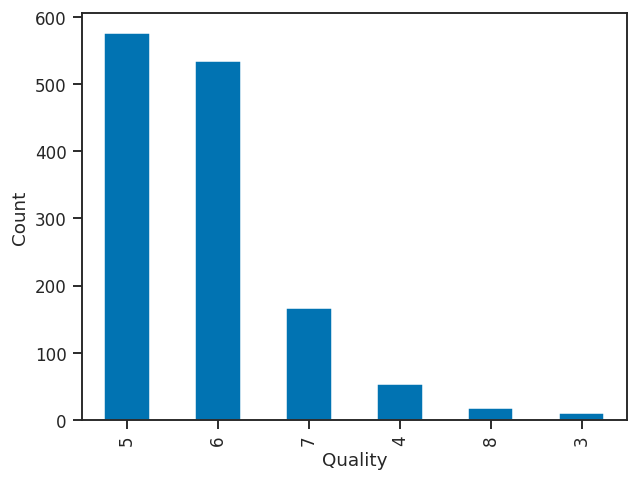

In [ ]:
# TODO: look at the distribution of `quality`
# (value_counts() and/or a histogram are both fine)

print(df['quality'].value_counts())

# Quality distribution
df['quality'].value_counts().plot.bar()
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

In [ ]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.

X = df.drop(columns='quality')
y = df['quality']

# Standardise predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [ ]:
# TODO: fit PCA on the standardised predictor matrix

pca = PCA()
scores = pca.fit_transform(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

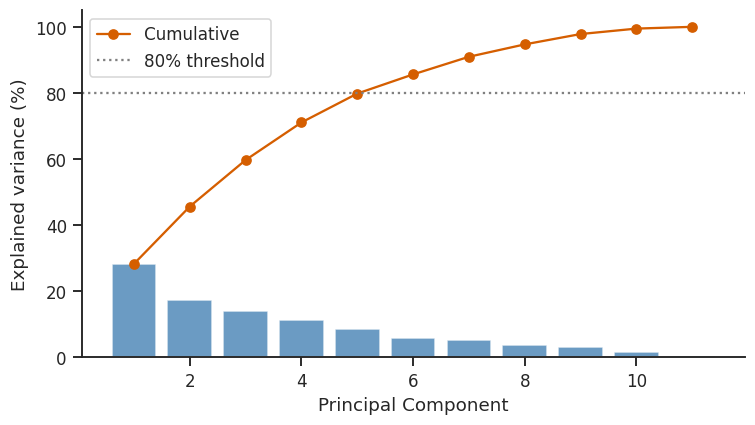

6 components: 85.6%


In [ ]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(1, len(explained)+1), explained*100,
       color='steelblue', alpha=0.8)
ax.plot(range(1, len(explained)+1), cumulative*100,
        'ro-', label='Cumulative')
ax.axhline(80, color='gray', ls=':', label='80% threshold')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Number of components needed for 80%
n_keep = np.argmax(cumulative >= 0.80) + 1
print(f'{n_keep} components: {cumulative[n_keep-1]*100:.1f}%')

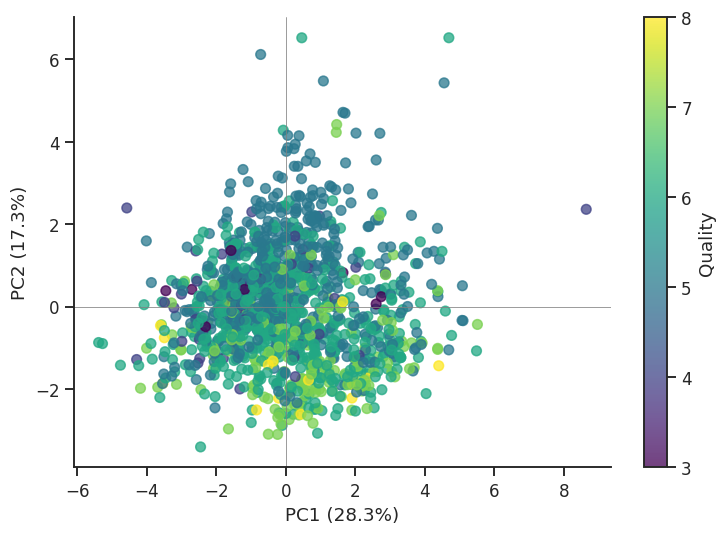

In [ ]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(scores[:, 0], scores[:, 1],
                c=y, cmap='viridis', s=40, alpha=0.75)

plt.colorbar(sc, ax=ax, label='Quality')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

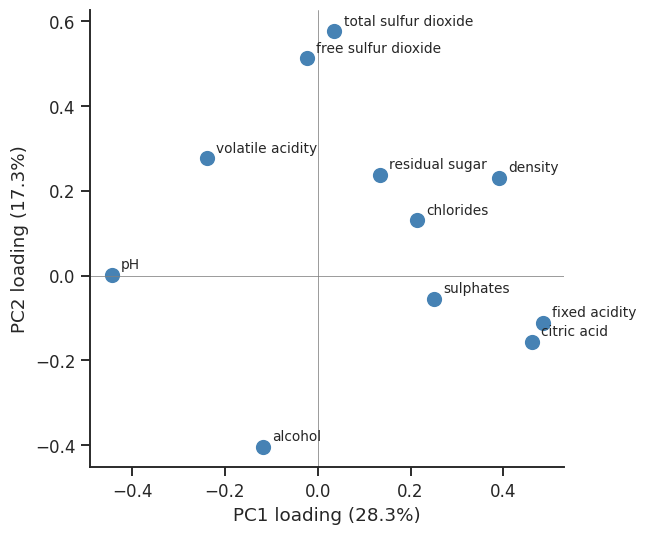

fixed acidity    0.485314
citric acid      0.462539
dtype: float64


In [143]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?

loadings = pca.components_.T

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings[:, 0], loadings[:, 1],
           color='steelblue', s=80)

# Add variable names
for i, var in enumerate(X.columns):
    ax.annotate(var, (loadings[i, 0], loadings[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 loading ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 loading ({explained[1]*100:.1f}%)')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Two largest absolute PC1 loadings
coef_pca = pd.Series(
    abs(pca.components_[0]),
    index=X.columns
)

print(coef_pca.nlargest(2))

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

In [ ]:
# TODO: train/test split (or set up cross-validation)

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

Optimal number of components: 5 (RMSECV = 0.664, Q2 = 0.350)


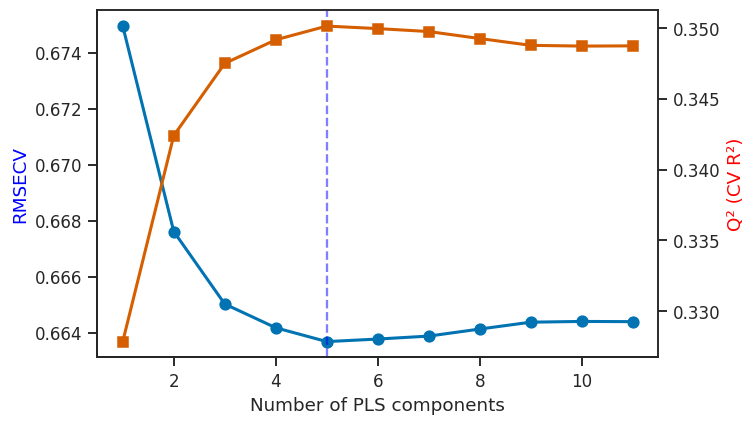

In [ ]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone

max_comp = X.shape[1]
rmsecv = []
q2 = []

for nc in range(1, max_comp + 1):
    pls_tmp = PLSRegression(n_components=nc, scale=False)
    y_cv = cross_val_predict(pls_tmp, X_scaled, y, cv=kf).ravel()

    rmsecv.append(np.sqrt(mean_squared_error(y, y_cv)))
    q2.append(r2_score(y, y_cv))

opt_nc = np.argmin(rmsecv) + 1

print(f'Optimal number of components: {opt_nc} '
      f'(RMSECV = {rmsecv[opt_nc-1]:.3f}, '
      f'Q2 = {q2[opt_nc-1]:.3f})')

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(range(1, max_comp+1), rmsecv,
         'bo-', lw=2, ms=7, label='RMSECV')
ax1.axvline(opt_nc, color='blue', ls='--', alpha=0.5)

ax2.plot(range(1, max_comp+1), q2,
         'rs-', lw=2, ms=7, label='Q²')

ax1.set_xlabel('Number of PLS components')
ax1.set_ylabel('RMSECV', color='blue')
ax2.set_ylabel('Q² (CV R²)', color='red')

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

R²      (train) = 0.363
Q²      (CV)    = 0.350
RMSECV          = 0.664


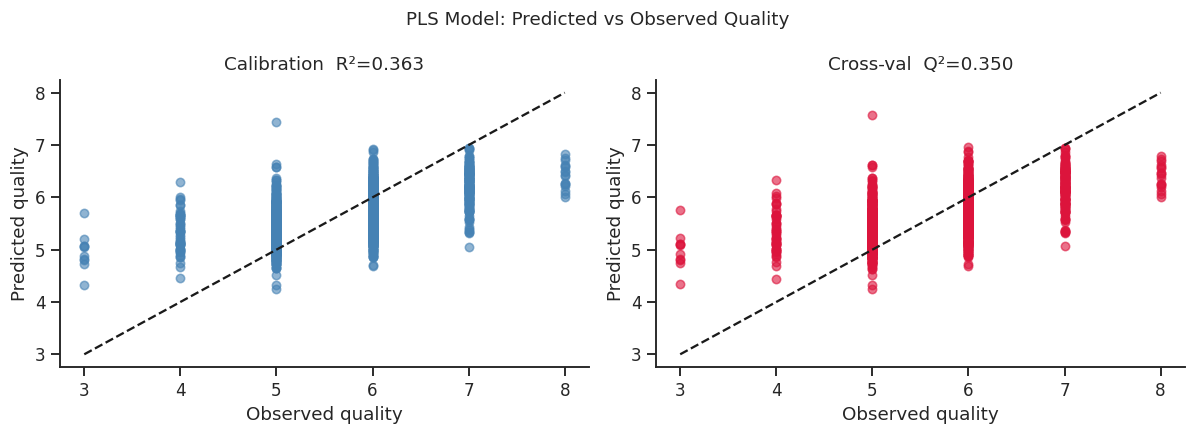

In [141]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)

# Fit final PLS model
pls = PLSRegression(n_components=opt_nc, scale=False)
pls.fit(X_scaled, y)

# Calibration and cross-validated predictions
y_pred_train = pls.predict(X_scaled).ravel()
y_pred_cv = cross_val_predict(pls, X_scaled, y, cv=kf).ravel()

r2_train = r2_score(y, y_pred_train)
q2_cv = r2_score(y, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))

print(f'R²      (train) = {r2_train:.3f}')
print(f'Q²      (CV)    = {q2_cv:.3f}')
print(f'RMSECV          = {rmse_cv:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (y_p, label, color) in zip(
    axes,
    [(y_pred_train, f'Calibration  R²={r2_train:.3f}', 'steelblue'),
     (y_pred_cv, f'Cross-val  Q²={q2_cv:.3f}', 'crimson')]
):
    ax.scatter(y, y_p, s=30, alpha=0.6, color=color)

    lims = [min(y.min(), y_p.min()),
            max(y.max(), y_p.max())]

    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlabel('Observed quality')
    ax.set_ylabel('Predicted quality')
    ax.set_title(label)
    sns.despine(ax=ax)

plt.suptitle('PLS Model: Predicted vs Observed Quality', fontsize=12)
plt.tight_layout()
plt.show()

### LDA (quality binned into categories)

In [ ]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

# low <= 5, medium = 6, high >= 7
y_class = pd.cut(
    y, [-np.inf, 5, 6, np.inf],
    labels=['low', 'medium', 'high']
)

print(y_class.value_counts())

quality
low       640
medium    535
high      184
Name: count, dtype: int64


In [ ]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis

X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_scaled, y_class, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_class
)

# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lda, y_train_lda)

y_pred_lda = lda.predict(X_test_lda)

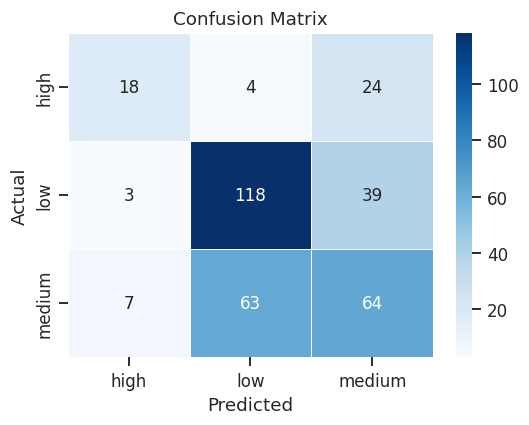

Classification report (test set):
              precision    recall  f1-score   support

        high       0.64      0.39      0.49        46
         low       0.64      0.74      0.68       160
      medium       0.50      0.48      0.49       134

    accuracy                           0.59       340
   macro avg       0.59      0.54      0.55       340
weighted avg       0.59      0.59      0.58       340

Majority baseline: 0.471


In [ ]:
# TODO: report a confusion matrix (ConfusionMatrixDisplay) and per-class
# accuracy on the TEST set -- accuracy alone is not enough here

grades_list = lda.classes_

cm = confusion_matrix(y_test_lda, y_pred_lda, labels=grades_list)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grades_list,
            yticklabels=grades_list,
            linewidths=0.5, ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print('Classification report (test set):')
print(classification_report(
    y_test_lda,
    y_pred_lda,
    labels=grades_list,
    target_names=grades_list
))

# Majority-class baseline
majority = y_train_lda.value_counts().idxmax()
print(f'Majority baseline: {(y_test_lda == majority).mean():.3f}')

In [146]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.

coef_pls = pd.Series(abs(pls.coef_.ravel()), index=X.columns)

coef_lda = pd.Series(abs(lda.coef_).mean(axis=0),index=X.columns)

coef_pca = pd.Series(abs(pca.components_[0]),index=X.columns)

print('PLS:')
print(coef_pls.nlargest(2))

print('\nLDA:')
print(coef_lda.nlargest(2))

print('\nPCA:')
print(coef_pca.nlargest(2))

PLS:
alcohol             0.281918
volatile acidity    0.196917
dtype: float64

LDA:
alcohol      0.708184
sulphates    0.378191
dtype: float64

PCA:
fixed acidity    0.485314
citric acid      0.462539
dtype: float64


---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Duplicates: 937
quality
6    1788
5    1175
7     689
4     153
8     131
3      20
9       5
Name: count, dtype: int64


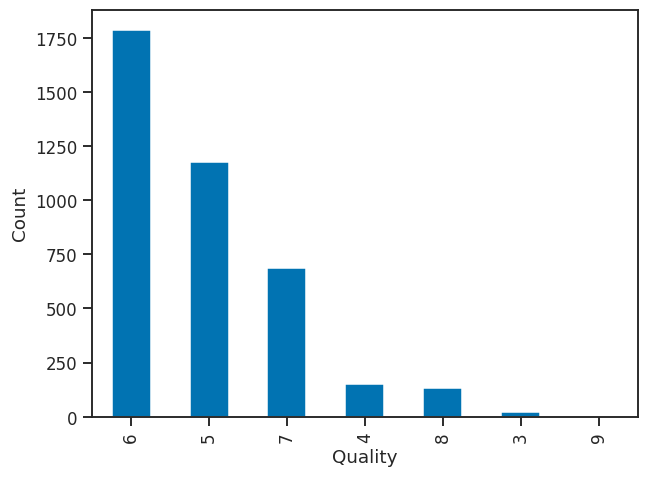

In [ ]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)

df_white = pd.read_csv('winequality-white.csv', sep=';')

print(df_white.isna().sum())
print('Duplicates:', df_white.duplicated().sum())

# Remove duplicates
df_white = df_white.drop_duplicates()

print(df_white['quality'].value_counts())

# Quality distribution
df_white['quality'].value_counts().plot.bar()
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

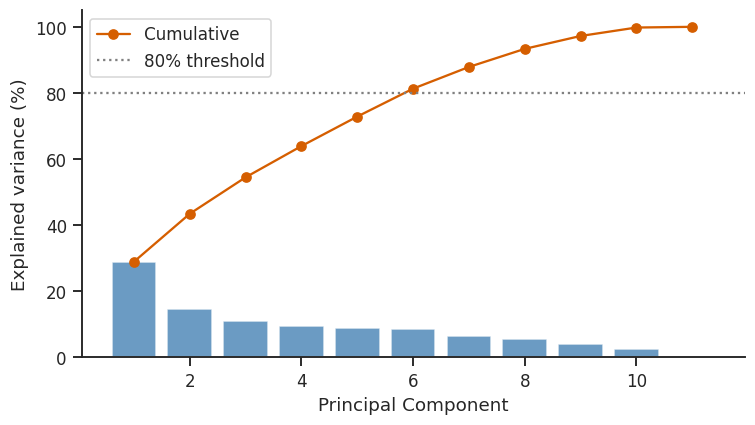

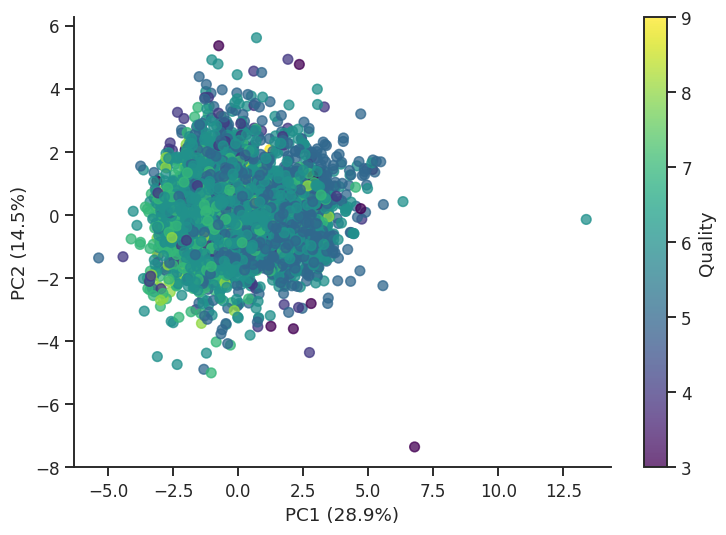

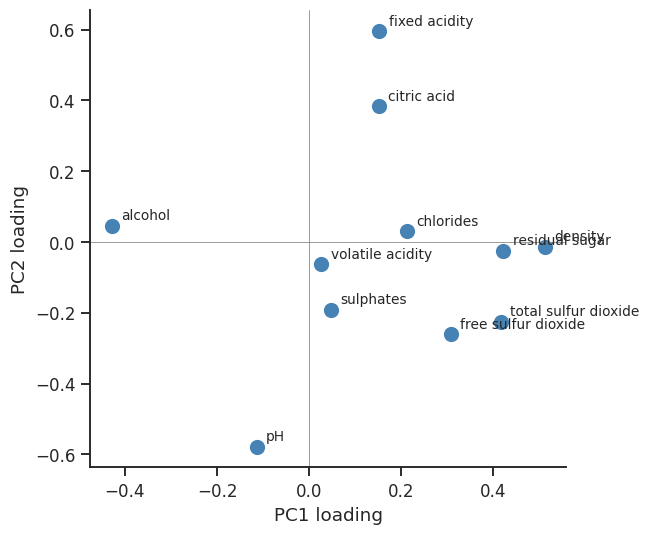

fixed acidity    0.485314
citric acid      0.462539
dtype: float64
density    0.512038
alcohol    0.428525
dtype: float64


In [147]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).

X_white = df_white.drop(columns='quality')
y_white = df_white['quality']

# Standardise and fit PCA
X_white_scaled = StandardScaler().fit_transform(X_white)

pca_white = PCA()
scores_white = pca_white.fit_transform(X_white_scaled)
explained_white = pca_white.explained_variance_ratio_
cumulative_white = np.cumsum(explained_white)

# Scree plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained_white)+1), explained_white*100,
       color='steelblue', alpha=0.8)
ax.plot(range(1, len(explained_white)+1), cumulative_white*100,
        'ro-', label='Cumulative')
ax.axhline(80, color='gray', ls=':', label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Score plot
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(scores_white[:, 0], scores_white[:, 1],
                c=y_white, cmap='viridis', s=40, alpha=0.75)
plt.colorbar(sc, ax=ax, label='Quality')
ax.set_xlabel(f'PC1 ({explained_white[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_white[1]*100:.1f}%)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Loading plot
loadings_white = pca_white.components_.T

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings_white[:, 0], loadings_white[:, 1],
           color='steelblue', s=80)

for i, var in enumerate(X_white.columns):
    ax.annotate(var, (loadings_white[i, 0], loadings_white[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('PC1 loading')
ax.set_ylabel('PC2 loading')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Compare strongest PC1 loadings
coef_pca = pd.Series(abs(pca.components_[0]),index=X.columns)
coef_pca_white = pd.Series(abs(pca_white.components_[0]),index=X.columns)

print(coef_pca.nlargest(2))
print(coef_pca_white.nlargest(2))

Optimal number of components: 6 (RMSECV = 0.750, Q2 = 0.291)


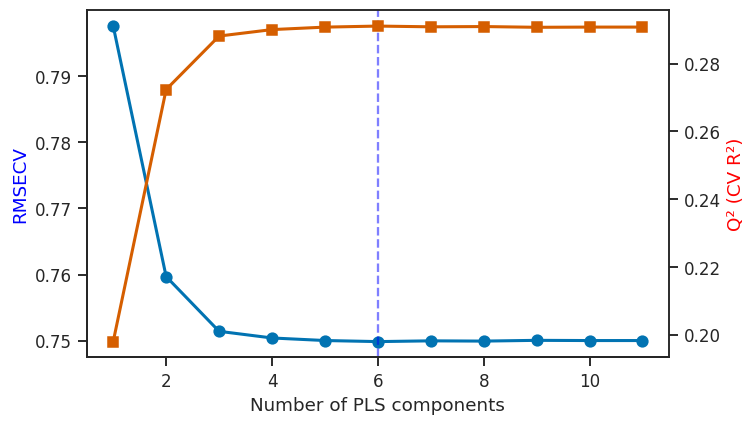

R²      (train) = 0.297
Q²      (CV)    = 0.291
RMSECV          = 0.750


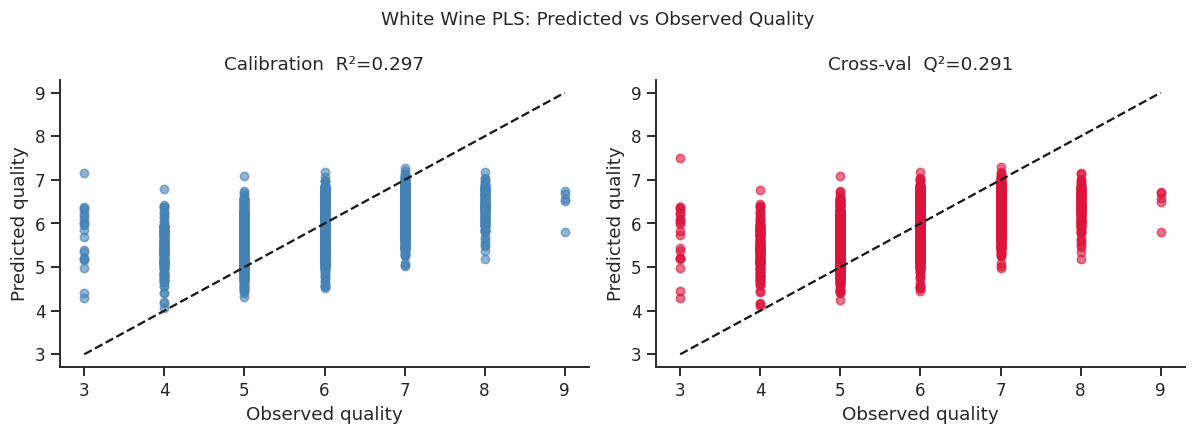

Red wine:
Q² = 0.350, RMSECV = 0.664, R² = 0.363

White wine:
Q² = 0.291, RMSECV = 0.750, R² = 0.297 

Red:
alcohol             0.281918
volatile acidity    0.196917
dtype: float64

White:
alcohol           0.363889
residual sugar    0.207079
dtype: float64


In [152]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 4b).

# Choose number of PLS components using 10-fold cross-validation
max_comp_white = X_white.shape[1]
rmsecv_white = []
q2_white = []

for nc in range(1, max_comp_white + 1):
    pls_tmp = PLSRegression(n_components=nc, scale=False)

    yw_cv = cross_val_predict(
        pls_tmp, X_white_scaled, y_white, cv=kf
    ).ravel()

    rmsecv_white.append(
        np.sqrt(mean_squared_error(y_white, yw_cv))
    )

    q2_white.append(
        r2_score(y_white, yw_cv)
    )

opt_nc_white = np.argmin(rmsecv_white) + 1

print(f'Optimal number of components: {opt_nc_white} '
      f'(RMSECV = {rmsecv_white[opt_nc_white-1]:.3f}, '
      f'Q2 = {q2_white[opt_nc_white-1]:.3f})')


# Component selection plot
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(
    range(1, max_comp_white + 1),
    rmsecv_white,
    'bo-', lw=2, ms=7, label='RMSECV'
)

ax1.axvline(
    opt_nc_white,
    color='blue', ls='--', alpha=0.5
)

ax2.plot(
    range(1, max_comp_white + 1),
    q2_white,
    'rs-', lw=2, ms=7, label='Q²'
)

ax1.set_xlabel('Number of PLS components')
ax1.set_ylabel('RMSECV', color='blue')
ax2.set_ylabel('Q² (CV R²)', color='red')

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()


# Fit final PLS model
pls_white = PLSRegression(
    n_components=opt_nc_white,
    scale=False
)

pls_white.fit(X_white_scaled, y_white)


# Calibration and cross-validated predictions
yw_pred_train = pls_white.predict(
    X_white_scaled
).ravel()

yw_pred_cv = cross_val_predict(
    pls_white,
    X_white_scaled,
    y_white,
    cv=kf
).ravel()


# Performance
r2_train_white = r2_score(
    y_white, yw_pred_train
)

q2_cv_white = r2_score(
    y_white, yw_pred_cv
)

rmse_cv_white = np.sqrt(
    mean_squared_error(y_white, yw_pred_cv)
)

print(f'R²      (train) = {r2_train_white:.3f}')
print(f'Q²      (CV)    = {q2_cv_white:.3f}')
print(f'RMSECV          = {rmse_cv_white:.3f}')


# Predicted vs observed
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (y_p, label, color) in zip(
    axes,
    [
        (yw_pred_train,
         f'Calibration  R²={r2_train_white:.3f}',
         'steelblue'),

        (yw_pred_cv,
         f'Cross-val  Q²={q2_cv_white:.3f}',
         'crimson')
    ]
):

    ax.scatter(
        y_white, y_p,
        s=30, alpha=0.6,
        color=color
    )

    lims = [
        min(y_white.min(), y_p.min()),
        max(y_white.max(), y_p.max())
    ]

    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlabel('Observed quality')
    ax.set_ylabel('Predicted quality')
    ax.set_title(label)

    sns.despine(ax=ax)

plt.suptitle(
    'White Wine PLS: Predicted vs Observed Quality',
    fontsize=12
)

plt.tight_layout()
plt.show()


# Compare red and white wine performance
print('Red wine:')
print(f'Q² = {q2_cv:.3f}, RMSECV = {rmse_cv:.3f}, R² = {r2_train:.3f}')

print('\nWhite wine:')
print(f'Q² = {q2_cv_white:.3f}, RMSECV = {rmse_cv_white:.3f}, R² = {r2_train_white:.3f} ')


# Compare important variables
coef_white = pd.Series(
    abs(pls_white.coef_.ravel()),
    index=X_white.columns
)

print('\nRed:')
print(coef_pls.nlargest(2))

print('\nWhite:')
print(coef_white.nlargest(2))

---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.